In [1]:
#==============================================================================================
# IMPORTS
#==============================================================================================
import numpy as np
import matplotlib.pyplot as plt
import h5py
import io_functions as io
import matplotlib.tri as tri
from matplotlib.tri import Triangulation
from scipy.interpolate import griddata
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import pandas as pd
import os
from skimage import feature
from scipy import ndimage
import matplotlib.gridspec as gridspec
import pickle

In [45]:
#load data
filename = 'TDGL_NiobiumDiselenide_Only.h5'

In [3]:
# for sweep 1 to 30
all_sol, I_values = io.load_all_sol_manual(filename)

with h5py.File(filename, 'r') as f:
   V_0_dev = f['metadata'].attrs['V_0_dev']


Loading from: TDGL_NiobiumDiselenide_Only.h5...
 Loaded from: TDGL_NiobiumDiselenide_Only.h5



In [4]:
I = 10  #μA example current
I_values = np.linspace(1,30,30)

# Extract all voltages for both 'up' and 'down' sweeps
voltages_up = {}
voltages_down = {}

# Up sweep
for B in all_sol[I]['up'].keys():
    if 'voltage' in all_sol[I]['up'][B]:
        voltages_up[B] = all_sol[I]['up'][B]['voltage']

# Down sweep
for B in all_sol[I]['down'].keys():
    if 'voltage' in all_sol[I]['down'][B]:
        voltages_down[B] = all_sol[I]['down'][B]['voltage']

# Sorted from low to high
B_values_up = sorted(voltages_up.keys())
V_values_up = [voltages_up[B] for B in B_values_up]

B_values_down = sorted(voltages_down.keys())
V_values_down = [voltages_down[B] for B in B_values_down]

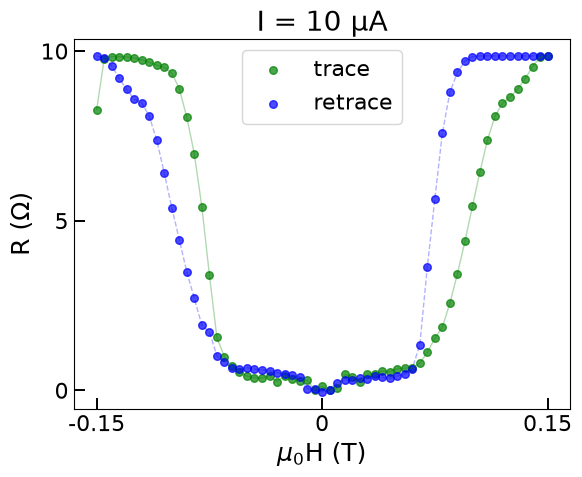

In [5]:
#======================================================================================
# Plot Example RB Graph
#======================================================================================

# Extract data and plot for all currents
n_currents = len(I_values)

#convert current to amperes
I_Amps = np.array(I)
I_Amps = I_Amps*1e-6

#convert magnetic field to Tesla
B_values_up = np.array(B_values_up)
B_values_down = np.array(B_values_down)
B_up_T = 0.001*B_values_up
B_down_T = 0.001*B_values_down

#convert from units V_0 to V
V_up = np.array(V_values_up) #convert to numpy array
V_down = np.array(V_values_down) # to make element-wise division possible
V_up_V = V_up*V_0_dev
V_down_V = V_down*V_0_dev

# Convert to resistance (Ohms)
R_up_mO = 1000*(V_up_V/I_Amps)
R_down_mO = 1000*(V_down_V/I_Amps)

plt.scatter(B_up_T, R_up_mO, c='green', s=30, label='trace', alpha=0.7)
plt.scatter(B_down_T, R_down_mO, c='blue', s=30, label='retrace', alpha=0.7)
plt.plot(B_up_T, R_up_mO, c='green', alpha=0.3, linewidth=1)
plt.plot(B_down_T, R_down_mO, c='blue', alpha=0.3, linestyle='--', linewidth=1)
plt.xlabel("$\mu_0$H (T)", fontsize = 18)
plt.ylabel("R ($\Omega$)", fontsize = 18)
plt.xticks([-0.15,0,0.15],['-0.15', '0', '0.15'], fontsize = 16)
plt.yticks([0,5,10],['0', '5', '10'], fontsize = 16)
plt.tick_params(
    direction='in',      # Ticks point INWARD
    length=8,            # Length of tick marks
    width=1.4,           # Width of tick line
    pad=4                # Space between ticks and numbers
)
plt.title(f"I = {I} μA", fontsize=20)
plt.legend(fontsize = 16)
plt.savefig('RB_graph.jpeg', dpi=300, bbox_inches='tight')
plt.show()

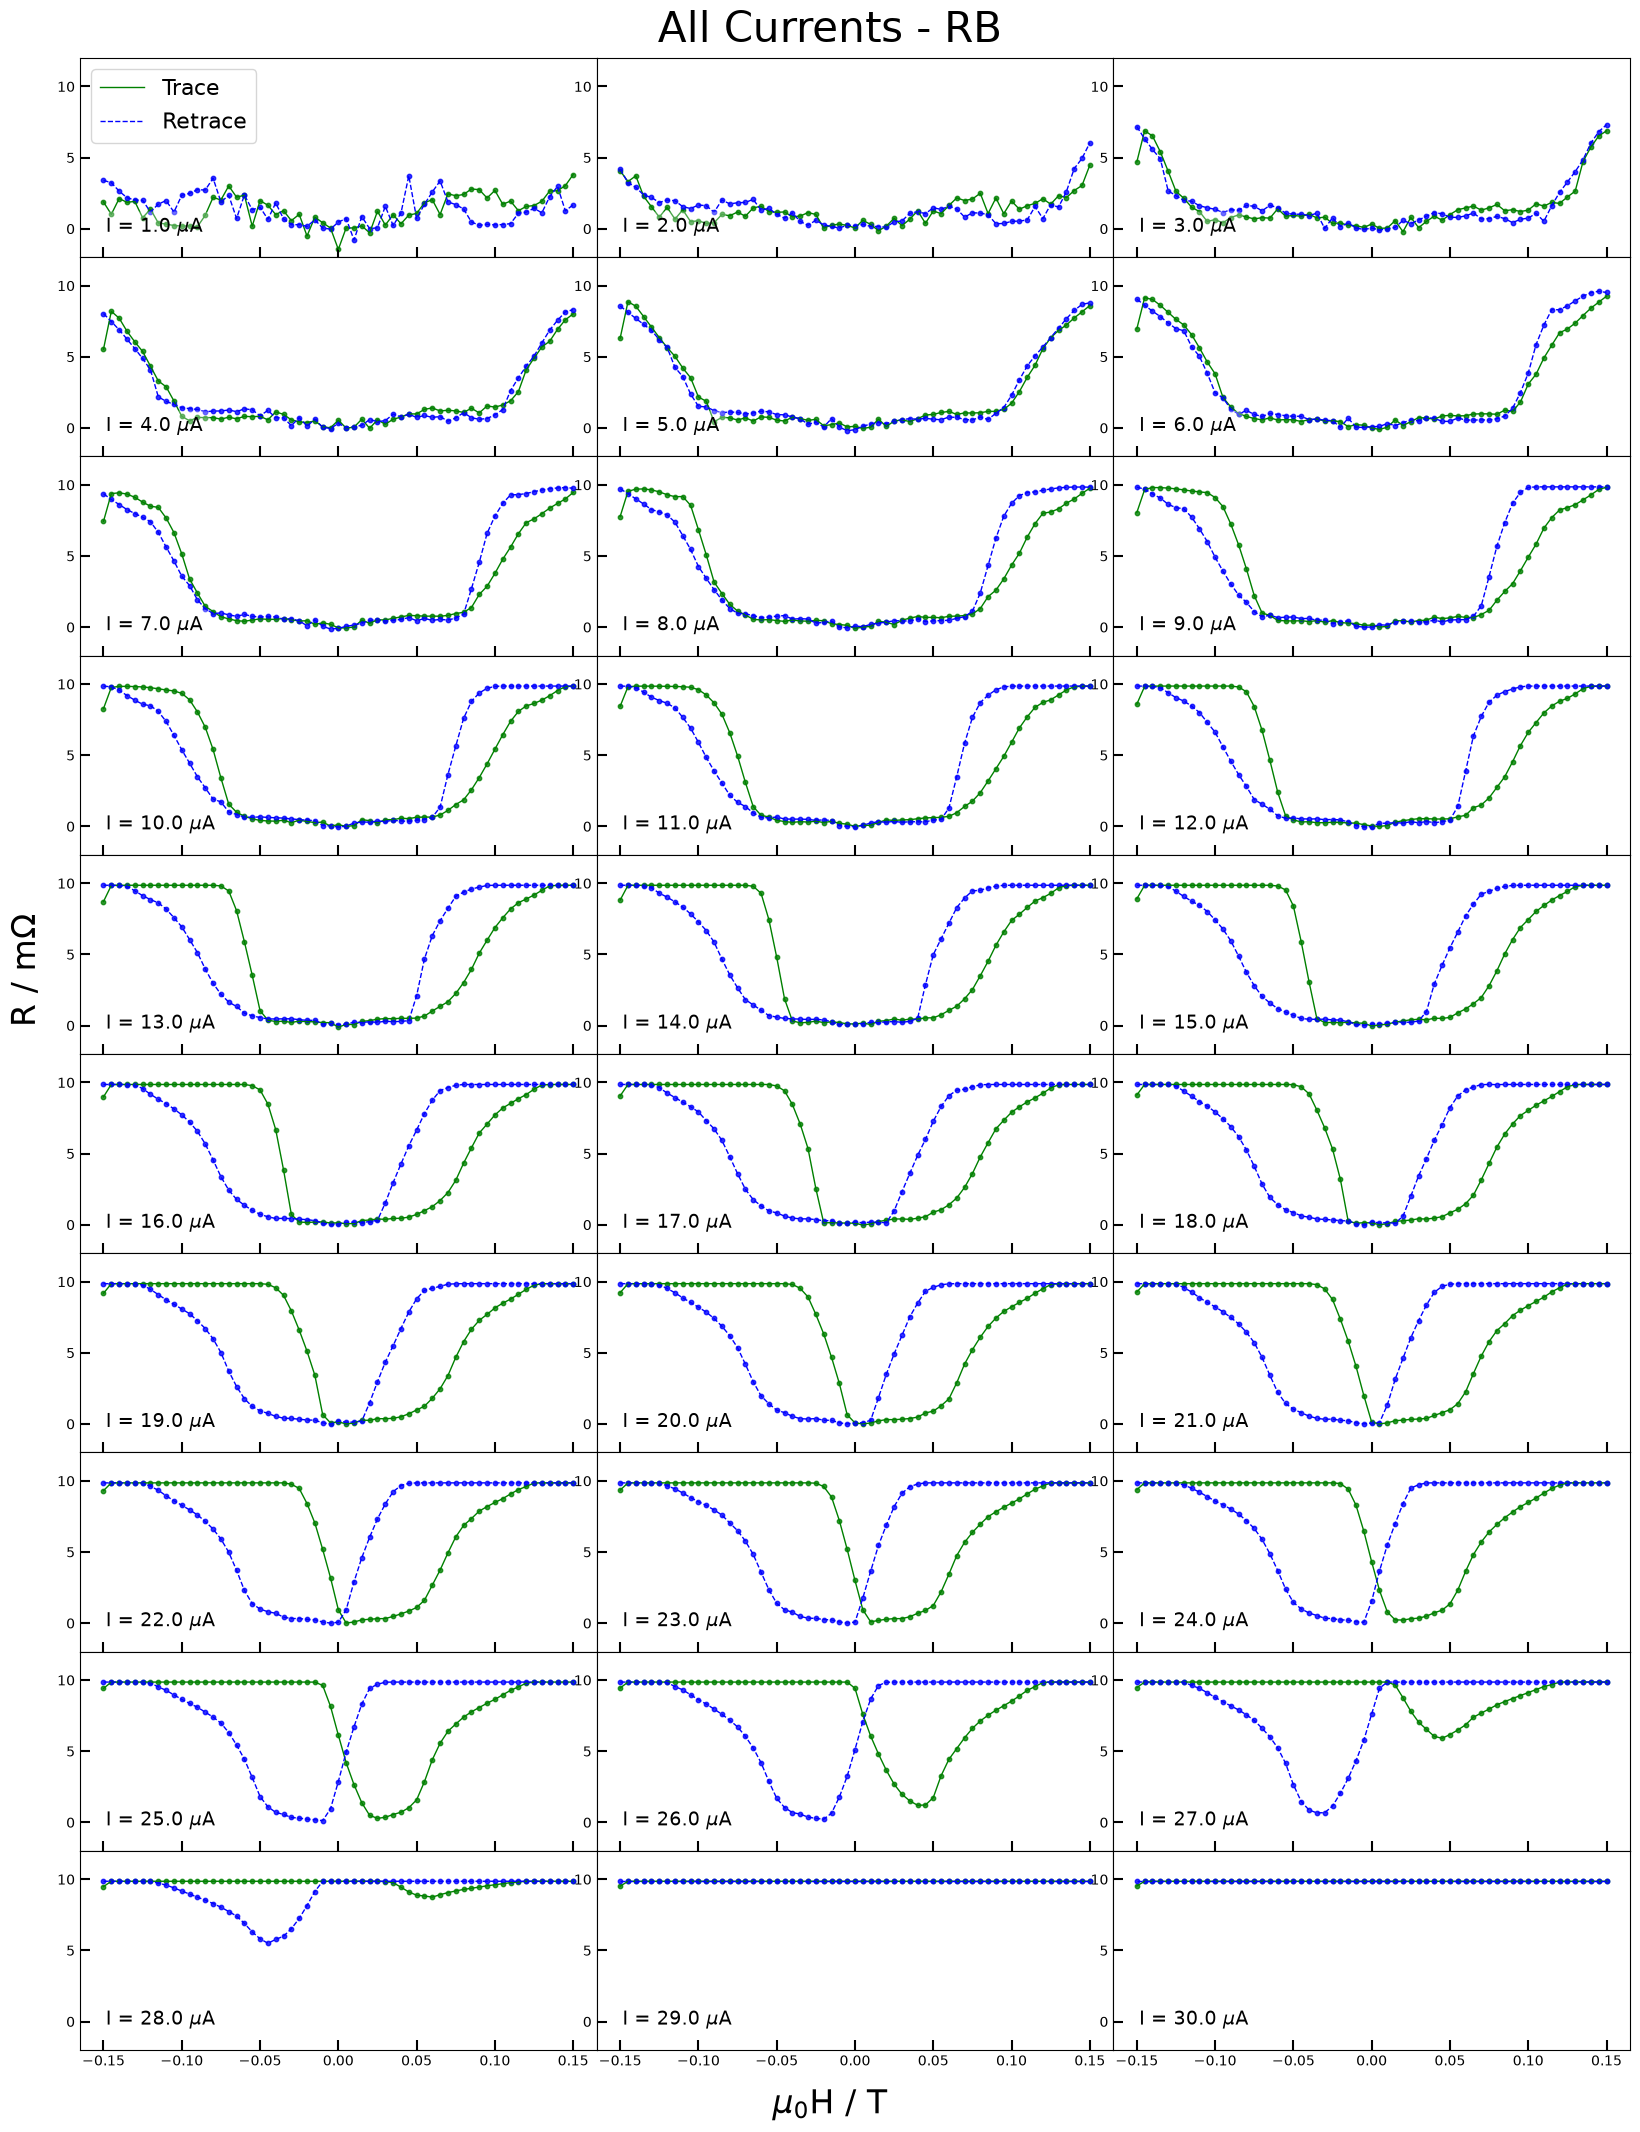

In [6]:
# ============================================================================
# STACKED R-B PLOTS FOR ALL CURRENTS
# ============================================================================

I_values = np.linspace(1,30,30)

# Get sorted current values (filter out 'mesh' key)
I_values_sorted = sorted([I for I in all_sol.keys() if I != 'mesh'])

n_currents = len(I_values)

# Create stacked subplots
fig, axes = plt.subplots(10, 3, figsize=(20, 24), sharex=True)
axes = axes.flatten()

# Handle single subplot case
if n_currents == 1:
    axes = [axes]

B_c2_up_dict = {}

# Plot R-B for each current
for idx, I in enumerate(I_values):
    ax = axes[idx]
    
    # Get B values and voltages for up sweep
    B_values_up = sorted(all_sol[I]['up'].keys())
    voltages_up = [all_sol[I]['up'][B]['voltage'] for B in B_values_up]
    
    # Get B values and voltages for down sweep
    B_values_down = sorted(all_sol[I]['down'].keys())
    voltages_down = [all_sol[I]['down'][B]['voltage'] for B in B_values_down]

    #convert B values to Tesla
    B_values_down = np.array(B_values_down)
    B_values_up = np.array(B_values_up)
    
    B_values_down = B_values_down/1000
    B_values_up = B_values_up/1000
    
    #convert voltages to volts
    voltages_up = np.array(voltages_up)
    voltages_down = np.array(voltages_down)
    V_up_V = voltages_up*V_0_dev
    V_down_V = voltages_down*V_0_dev
    
    # Calculate resistance R = V/I
    R_up_O = np.array(1000*V_up_V) / (I*1e-6)
    R_down_O = np.array(1000*V_down_V) / (I*1e-6)
    
    # Plot up and down sweeps
    ax.scatter(B_values_up, R_up_O, color='green', alpha=0.8, s=10)
    ax.scatter(B_values_down, R_down_O, color='blue', alpha=0.8, s=10)
    ax.plot(B_values_up, R_up_O, c='green', label='Trace', alpha=1, linewidth=1)
    ax.plot(B_values_down, R_down_O, c='blue', label='Retrace', alpha=1, linestyle='--', linewidth=1)
    ax.tick_params(direction='in', length=7.5,width=1.5)
    ax.set_ylim(-2,12)
    major_ticks = [0, 5,10]
    major_labels = [0,5,10]
    ax.set_yticks(major_ticks,labels=major_labels, minor=False)
    props = dict(boxstyle='round', facecolor='white', alpha=0.3, edgecolor='none')
    ax.text(0.05, 0.2, f'I = {I:.1f} $\mu$A', transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
    
    # Add legend to plot 1.
    if idx == 0:
        ax.legend(loc='upper left', fontsize=16)

fig.suptitle('All Currents - RB', fontsize=30, y=0.90)
fig.supylabel("R / m$\Omega$", fontsize = 24, x=0.09)
fig.supxlabel("$\mu_0$H / T", fontsize = 24, y=0.02)
fig.subplots_adjust(hspace=0, bottom =0.05, wspace=0)
plt.savefig('R_vs_B_stacked_all_currents.png', dpi=300, bbox_inches='tight')
plt.show()

<!-- | Current  | B_c2- | B_c1- | B_c1+ | B_c2+ |
| -------- | ------- | ------------- | ------- | ------- |
| 1 |  -->

In [7]:
#=======================================================================================================
# PHASE PLOT I-B
#=======================================================================================================

# Up Sweep - Extract Data
B_values_all = np.array(sorted(all_sol[I_values[0]]['up'].keys())) / 1000  # Convert to T

# Create 30x61 grid
n_currents = len(I_values)
n_B_values = len(B_values_all)
R_grid = np.zeros((n_currents, n_B_values))

# Fill the grid
for idx, I in enumerate(I_values):
    B_values = sorted(all_sol[I]['up'].keys())
    voltages = np.array([all_sol[I]['up'][B]['voltage'] for B in B_values])
    
    # Convert to milliOhms
    R_mO_sweep = (voltages * V_0_dev) / (I * 1e-6) * 1000
    R_grid[idx, :] = R_mO_sweep

I_grid = np.array(I_values)

# Define thresholds (in milli Ohms)
R_SC_threshold = 0.0986*1 #1% of R_normal
R_vortex_threshold =  0.0986*50 # 50% of R_normal

# Create phase grid using numpy conditions
phase_grid = np.zeros_like(R_grid, dtype=int)
phase_grid[R_grid >= R_SC_threshold] = 1
phase_grid[R_grid >= R_vortex_threshold] = 2

# Down Sweep - Extract data
B_values_all_down = np.array(sorted(all_sol[I_values[0]]['down'].keys())) / 1000
n_currents = len(I_values)
n_B_values = len(B_values_all_down)
R_grid_down = np.zeros((n_currents, n_B_values))

for idx, I in enumerate(I_values):
    B_values = sorted(all_sol[I]['down'].keys())
    voltages = np.array([all_sol[I]['down'][B]['voltage'] for B in B_values])
    R_mO_sweep = (voltages * V_0_dev) / (I * 1e-6) * 1000
    R_grid_down[idx, :] = R_mO_sweep

# DOWN SWEEP - Create phase grid
phase_grid_down = np.zeros_like(R_grid_down, dtype=int)
phase_grid_down[R_grid_down >= R_SC_threshold] = 1
phase_grid_down[R_grid_down >= R_vortex_threshold] = 2

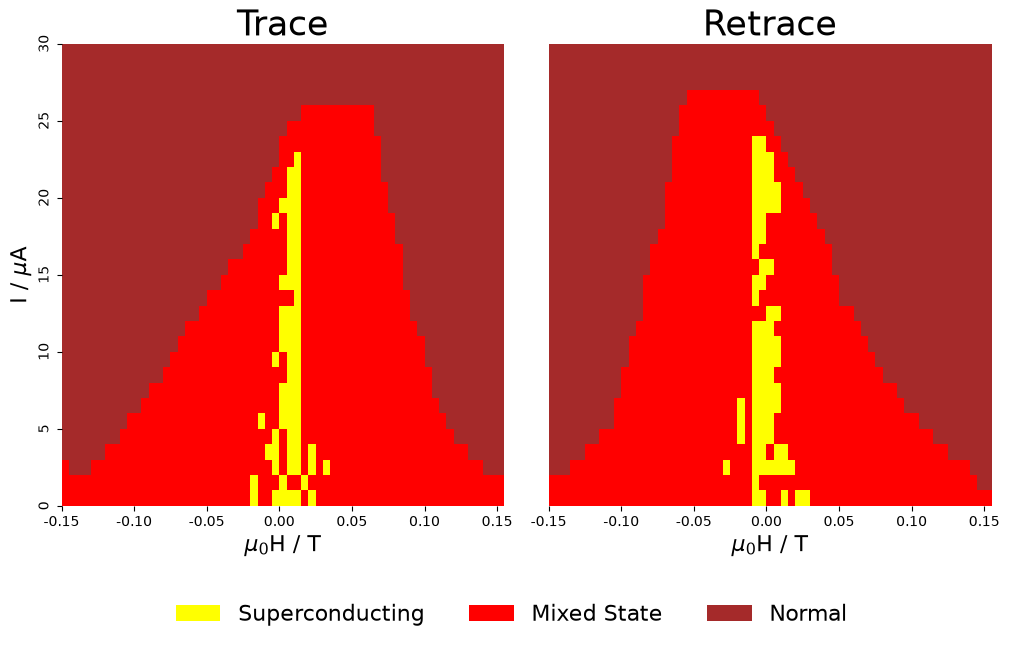

In [8]:
#===================================================================================================
# Plot Phase Portrait
#===================================================================================================

fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.1)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

colors = ['yellow', 'red', 'brown']
custom_cmap = ListedColormap(colors)
bounds = [0, 1, 2, 3]
norm = BoundaryNorm(bounds, custom_cmap.N)

# UP SWEEP
sns.heatmap(phase_grid, cmap=custom_cmap, norm=norm, ax=ax1,
            cbar=False, xticklabels=10, yticklabels=5)
ax1.invert_yaxis()
n_B_points = phase_grid.shape[1]
B_min = -0.15
B_max = 0.15

ax1.set_xticks(np.linspace(0, n_B_points-1, 7))
ax1.set_xticklabels([f'{B:.2f}' for B in np.linspace(B_min, B_max, 7)])
ax1.set_yticks([0, 5, 10, 15, 20, 25, 30])
ax1.set_yticklabels(['0', '5', '10', '15', '20', '25', '30'])
ax1.set_xlabel('$\mu_0$H / T', fontsize=16)
ax1.set_ylabel('I / $\mu$A', fontsize=16)
ax1.set_title('Trace', fontsize=25)

# DOWN SWEEP
sns.heatmap(phase_grid_down, cmap=custom_cmap, norm=norm, ax=ax2,
            cbar=False, xticklabels=10, yticklabels=5)
ax2.invert_yaxis()
ax2.set_xticks(np.linspace(0, n_B_points-1, 7))
ax2.set_xticklabels([f'{B:.2f}' for B in np.linspace(B_min, B_max, 7)])

ax2.set_yticks([])
ax2.set_xlabel('$\mu_0$H / T', fontsize=16)
ax2.set_title('Retrace', fontsize=25)

# Single legend for both
legend_elements = [
    Patch(facecolor=colors[0], label='Superconducting'),
    Patch(facecolor=colors[1], label='Mixed State'),
    Patch(facecolor=colors[2], label='Normal')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=3, fontsize=16, frameon=False)

plt.savefig('bare_phases.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
#========================================================================================
#code used to inspect R-B sweep values (at specific currents)
#========================================================================================

I_test = 5  # Change this to desired current

B_values = np.array(sorted(all_sol[I_test]['up'].keys())) / 1000
voltages = np.array([all_sol[I_test]['up'][B]['voltage'] for B in sorted(all_sol[I_test]['up'].keys())])
R_mO = (voltages * V_0_dev) / (I_test * 1e-6) * 1000

# Create DataFrame for easy viewing
df_inspect = pd.DataFrame({
    'B (T)': B_values,
    'V (raw)': voltages,
    'R (mΩ)': R_mO
})

print(f"Current I = {I_test} μA")
print(f"Total points: {len(df_inspect)}")
print("threshold Bc2+ is", f'{9.858/2}')
print("threshold Bc1+ is", f'{9.858/100}')
print("threshold Bc2- is", f'{9.858/2}')
print("threshold Bc1- is", f'{9.858/100}')
print("\n" + df_inspect.to_string())

Current I = 5 μA
Total points: 61
threshold Bc2+ is 4.929
threshold Bc1+ is 0.09858
threshold Bc2- is 4.929
threshold Bc1- is 0.09858

    B (T)   V (raw)    R (mΩ)
0  -0.150  0.775104  6.308303
1  -0.145  1.090068  8.871688
2  -0.140  1.051320  8.556327
3  -0.135  0.961706  7.826989
4  -0.130  0.870979  7.088593
5  -0.125  0.780475  6.352012
6  -0.120  0.694207  5.649912
7  -0.115  0.618954  5.037450
8  -0.110  0.517651  4.212980
9  -0.105  0.433382  3.527146
10 -0.100  0.267207  2.174707
11 -0.095  0.230145  1.873072
12 -0.090  0.053417  0.434745
13 -0.085  0.091499  0.744680
14 -0.080  0.087302  0.710519
15 -0.075  0.068197  0.555032
16 -0.070  0.087411  0.711405
17 -0.065  0.059340  0.482944
18 -0.060  0.096063  0.781820
19 -0.055  0.091008  0.740684
20 -0.050  0.067276  0.547539
21 -0.045  0.059856  0.487144
22 -0.040  0.092742  0.754791
23 -0.035  0.080290  0.653454
24 -0.030  0.065989  0.537062
25 -0.025  0.073871  0.601208
26 -0.020  0.018944  0.154182
27 -0.015  0.028750  0.23

## Full Critical H-field values data for I-Sweep

These data were found manually by inspecting the data in the R-B sweeps using the command in the cell above.
The method was the first value to cross the threshold. The nearest value of that and the previous one. 
The thresholds used were < 1% R_max for superconducting and < 50% R_max for vortex state.

|I ($\mu A$)|B$_{c2-}$ (T)|B$_{c1-}$(T)|B$_{c1+}$(T)|B$_{c2+}$(T)|
|---|----|----|----|----|
|1|-0.085|-0.015|0.015|0.085|
|2|-0.070|-0.030|N/A|0.070|
|3|-0.055|-0.015|0.015|0.055|
|4|-0.045|-0.015|0.015|0.045|
|5|-0.040|-0.015|0.015|0.040|
|6|-0.035|-0.015|0.015|0.035|
|7|-0.035|-0.015|0.015|0.035|
|8|-0.035|-0.015|N/A|0.035|
|9|-0.035|N/A|N/A|0.035|
|10|-0.035|N/A|N/A|0.035|
|11|-0.035|N/A|N/A|0.035|
|12|-0.035|N/A|N/A|0.035|
|13|-0.035|N/A|N/A|0.030|
|14|-0.035|N/A|N/A|0.030|
|15|-0.035|N/A|N/A|0.030|
|16|-0.035|N/A|N/A|N/A|
|17|-0.030|N/A|N/A|N/A|
|18|-0.030|N/A|N/A|N/A|
|19|normal everywhere|
|20|normal everywhere|
|21|normal everywhere|
|22|normal everywhere|
|23|normal everywhere|
|24|normal everywhere|
|25|normal everywhere|
|26|normal everywhere|
|27|normal everywhere|
|28|normal everywhere|
|29|normal everywhere|
|30|normal everywhere|



Selected current: I = 5 μA



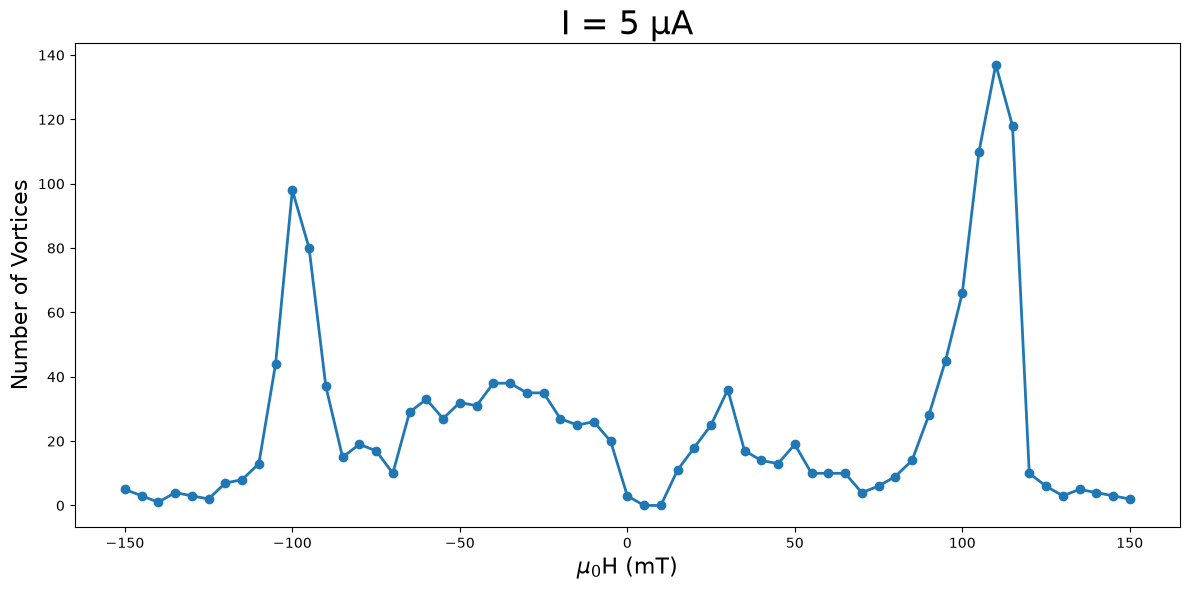

In [59]:
#==============================================================================================
# Vortex Count plot for select I-Values
#==============================================================================================

# Make sure this matches the filename of the .pkl file
with open('vortex_count_dict_adaptive_final_bare.pkl', 'rb') as f:
    vortex_count = pickle.load(f)

# Choose a current value
I_selected = I_values[4]  # Change this to select different current (remember zero indexing so 4 means 5 uA).

print(f"Selected current: I = {I_selected} μA\n")

# Extract up and down sweep data
up_data = vortex_count[I_selected]['up']
down_data = vortex_count[I_selected]['down']

# Convert to sorted arrays
B_fields = sorted(up_data.keys())
up_vortices = [up_data[B] for B in B_fields]
down_vortices = [down_data[B] for B in B_fields]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(B_fields, up_vortices, "o-", label='up sweep', linewidth=2, markersize=6)
#ax.plot(B_fields, down_vortices, 's-', label='Down sweep', linewidth=2, markersize=6) #comment out to plot down sweep instead

ax.set_xlabel('$\mu_0$H (mT)', fontsize=16)
ax.set_ylabel('Number of Vortices', fontsize=16)
ax.set_title(f'I = {I_selected} μA', fontsize=24)

plt.tight_layout()
plt.savefig(f'vortex_plot_I{I_selected}.png', dpi=150)
plt.show()

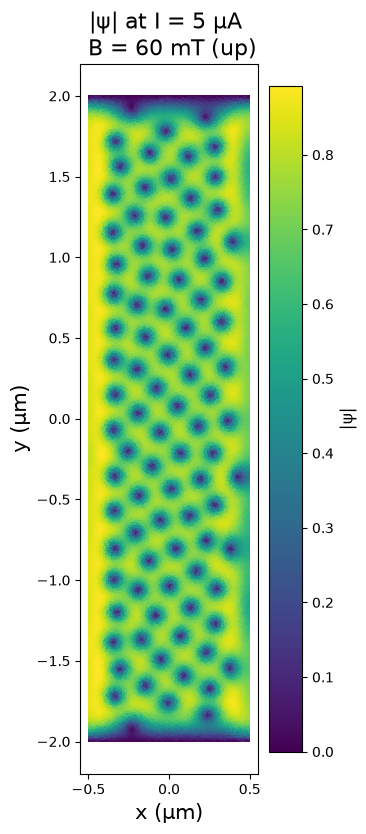

In [68]:
#==============================================================================================================
# Plot order parameter for select current and field.
#==============================================================================================================
with h5py.File(filename, 'r') as f:
    mesh = f['metadata']['mesh']
    coordinates = mesh['coordinates'][:]
    triangulation = mesh['triangulation'][:]

# Scale to physical device size
scale = 1.0 / 18.62
coordinates_scaled = coordinates * scale
tri_obj = Triangulation(coordinates_scaled[:, 0], coordinates_scaled[:, 1], triangulation)

# Select current, direction, and field value
current_idx = 5
direction = 'up'
field_value = 60  # in mT

psi_magnitude = all_sol[current_idx][direction][field_value]['psi_magnitude']

# Plot
fig, ax = plt.subplots(figsize=(3.75, 12))
tcf = ax.tripcolor(tri_obj, psi_magnitude, cmap='viridis', shading='flat')
ax.set_xlabel('x (μm)', fontsize=15)
ax.set_ylabel('y (μm)', fontsize=15)
ax.set_title(f'|ψ| at I = {current_idx} μA \n B = {field_value} mT ({direction})', fontsize=16)
ax.set_aspect('equal')

cbar = plt.colorbar(tcf, ax=ax)
cbar.set_label('|ψ|', fontsize=12)

plt.tight_layout()
plt.savefig('psi_heatmap.png', dpi=150)
plt.show()